### Fetch the directory listing and download the data

- `curl -s https://ftp.ncbi.nlm.nih.gov/pubchem/Bioassay/CSV/Data/ | grep -oP 'href="\K[0-9_]+\.zip' > filelist.txt`
- `xargs -n 1 -P 4 -I {} curl -O https://ftp.ncbi.nlm.nih.gov/pubchem/Bioassay/CSV/Data/{} < filelist.txt`


### Parse the data

In [1]:
import os
import zipfile
import pandas as pd
import glob
import numpy as np
import warnings
from pathlib import Path
import csv
import matplotlib.pyplot as plt
import re

In [2]:
# Data directory
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
Ebola_dataDir = dataDir + 'Ebola/'
Marburg_dataDir = dataDir + 'Marburg/' 
Lassa_dataDir = dataDir + 'Lassa/'
Nipah_dataDir = dataDir + 'Nipah/'
VEEV__dataDir = dataDir + 'VEEV/'
Hanta_dataDir = dataDir + 'Hanta/'
modelBuilding_dataDir = dataDir + 'modelBuildingData/'

# ChEMBL Bioassay Data for Ebola Virus

#### CSV Reader for ChEMBL Data

In [3]:
def readChemblCsvFile(filePath):
    """
    Read ChEMBL CSV file with proper handling of semicolon delimiter and quotes
    """
    print(f"Reading ChEMBL CSV file: {filePath}")
    
    try:
        # Method 1: Standard pandas with correct parameters
        dataFrame = pd.read_csv(
            filePath,
            sep=';',                        # Semicolon separator
            quotechar='"',                  # Double quotes
            quoting=csv.QUOTE_ALL,          # All fields quoted
            doublequote=True,               # Handle double quotes within quotes
            skipinitialspace=True,          # Skip spaces after delimiter
            on_bad_lines='skip',            # Skip malformed lines
            encoding='utf-8',
            low_memory=False                # Read entire file into memory for consistency
        )
        
        return dataFrame
        
    except Exception as e:
        print(f"Standard method failed: {e}")
        return None

In [4]:
# Load the dataset
chEMBLDataEbola = readChemblCsvFile(Ebola_dataDir + 'Ebola_bioactivity.csv')

if chEMBLDataEbola is not None:
    print(f"Dataset loaded successfully with Shape: {chEMBLDataEbola.shape}")
    #print(f"First few column names: {list(chEMBLDataEbola.columns[:5])}")
    #print(f"\nFirst row preview:")
    #print(chEMBLDataEbola.iloc[0])

Reading ChEMBL CSV file: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Ebola/Ebola_bioactivity.csv
Dataset loaded successfully with Shape: (956, 48)


#### Keep only relevant properties (columns) for ML model training

In [5]:
selectedColumns = ['Smiles', 'Standard Value', 'Standard Units', 'Standard Type', 
                  'Standard Relation', 'pChEMBL Value', 'Molecule ChEMBL ID',
                  'Molecular Weight', 'AlogP', 'Target ChEMBL ID',
                  'Target Name', 'Target Organism']

chEMBLDataEbola_cleaned = chEMBLDataEbola[[col for col in selectedColumns if col in chEMBLDataEbola.columns]].copy()

print(f"Dataset shape: {chEMBLDataEbola.shape} → {chEMBLDataEbola_cleaned.shape}")
chEMBLDataEbola_cleaned.to_csv(modelBuilding_dataDir+'EbolaBioassay_chEMBL_cleaned.csv', index=False)
chEMBLDataEbola_cleaned

Dataset shape: (956, 48) → (956, 12)


,Smiles,Standard Value,Standard Units,Standard Type,Standard Relation,pChEMBL Value,Molecule ChEMBL ID,Molecular Weight,AlogP,Target ChEMBL ID,Target Name,Target Organism
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,80000.0,/ml,Activity,'<',NaN,CHEMBL4065616,602.59,2.31,CHEMBL4434621,Ebolavirus,Ebolavirus
1,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,NaN,NaN,Activity,NaN,NaN,CHEMBL4065616,602.59,2.31,CHEMBL4434621,Ebolavirus,Ebolavirus
2,COc1nc(N)ncc1-c1cn(COCCO)cn1,100000.0,nM,EC50,'>',NaN,CHEMBL3596788,265.27,-0.10,CHEMBL4434621,Ebolavirus,Ebolavirus
3,Nc1nccc2c1ncn2[C@H]1C=C[C@H](O)[C@@H]1O,29.5,ug.mL-1,EC50,'=',NaN,CHEMBL4080961,232.24,-0.15,CHEMBL4434621,Ebolavirus,Ebolavirus
4,Nc1ncc(Br)c2c1ncn2[C@@H]1[C@@H](O)[C@@H](O)[C@...,NaN,NaN,Activity,NaN,NaN,CHEMBL4081268,325.17,0.69,CHEMBL4434621,Ebolavirus,Ebolavirus
...,...,...,...,...,...,...,...,...,...,...,...,...
951,CCN1CCN(CCCC(=O)O[C@H]2C(C)(C)[C@H]3CC[C@]2(C)...,5300.0,nM,IC50,'=',5.28,CHEMBL5591747,336.52,3.16,CHEMBL4434621,Ebolavirus,Ebolavirus
952,C[C@@H]1[C@H]2C[C@@H](C[C@H]1OC(=O)CN1CCN(C)CC...,34000.0,nM,IC50,'>',NaN,CHEMBL5592622,294.44,1.85,CHEMBL4434621,Ebolavirus,Ebolavirus
953,NC(=O)c1nc(F)cnc1O,61880.0,nM,EC50,'=',4.21,CHEMBL221722,157.10,-0.58,CHEMBL4434621,Ebolavirus,Ebolavirus
954,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCN1CCOCC1,34000.0,nM,IC50,'>',NaN,CHEMBL5595942,295.42,2.47,CHEMBL4434621,Ebolavirus,Ebolavirus


### Count  Standard Type

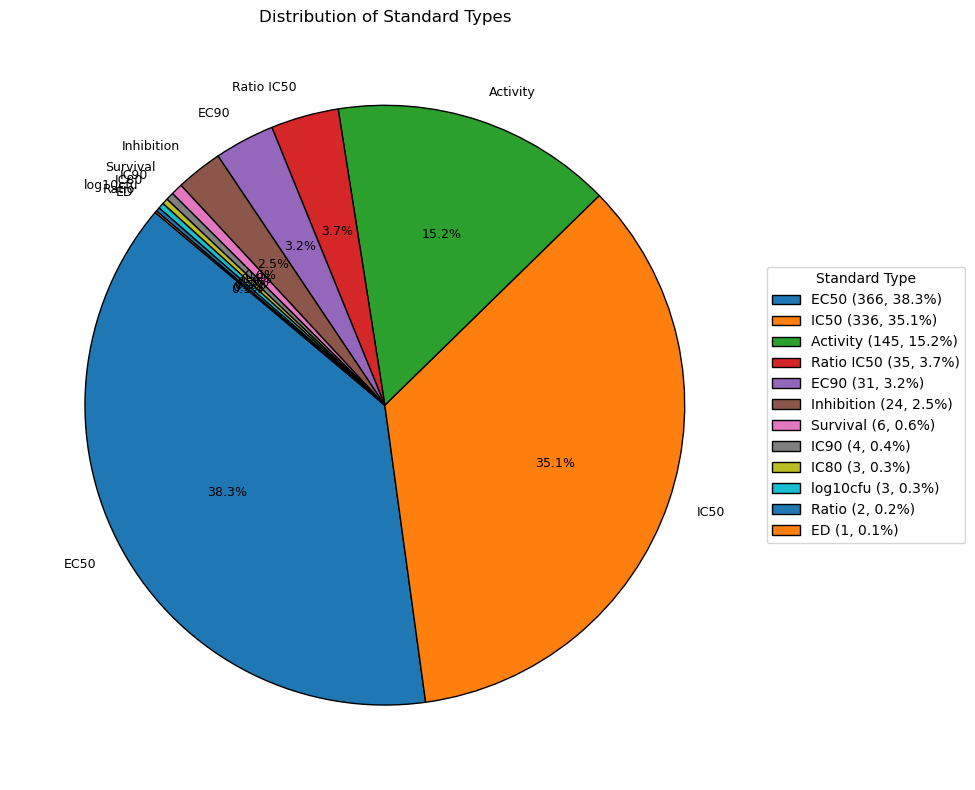

In [6]:
# Count occurrences of each Standard Type
type_counts = chEMBLDataEbola_cleaned["Standard Type"].value_counts()
total = type_counts.sum()

# Legend labels with counts and percentages
legend_labels = [
    f"{stype} ({count}, {count/total:.1%})"
    for stype, count in type_counts.items()
]

# Plot pie chart with inside labels showing just Standard Type
plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    type_counts,
    labels=type_counts.index,  # short labels inside slices
    autopct='%1.1f%%',         # show % inside too
    startangle=140,
    wedgeprops={'edgecolor': 'black'},
    textprops={'fontsize': 9}
)

# Legend with full details
plt.legend(
    wedges,
    legend_labels,
    title="Standard Type",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title("Distribution of Standard Types")
plt.tight_layout()
plt.show()

### check how many empty (NaN) values I have

In [7]:
nanCounts = chEMBLDataEbola_cleaned.isnull().sum()
totalRows = len(chEMBLDataEbola_cleaned)

for column, nanCount in nanCounts.items():
    percentage = (nanCount / totalRows) * 100
    print(f"{column:25s}: {nanCount:6,} ({percentage:5.1f}%)")

Smiles                   :      0 (  0.0%)
Standard Value           :     75 (  7.8%)
Standard Units           :    106 ( 11.1%)
Standard Type            :      0 (  0.0%)
Standard Relation        :     75 (  7.8%)
pChEMBL Value            :    347 ( 36.3%)
Molecule ChEMBL ID       :      0 (  0.0%)
Molecular Weight         :      0 (  0.0%)
AlogP                    :      6 (  0.6%)
Target ChEMBL ID         :      0 (  0.0%)
Target Name              :      0 (  0.0%)
Target Organism          :      0 (  0.0%)


### convert Standard Value + Standard Units + Standard Relation into a uniform numeric activity

### Count unique compounds in the 'Molecule ChEMBL ID' column

In [9]:
if "Molecule ChEMBL ID" in chEMBLDataEbola_cleaned.columns:
    unique_count = chEMBLDataEbola_cleaned["Molecule ChEMBL ID"].nunique()
    unique_values = chEMBLDataEbola_cleaned["Molecule ChEMBL ID"].unique()[:10]  # show first 10 unique values
else:
    unique_count = None
    unique_values = []

print (f"Number of unique compounds: {unique_count}")

Number of unique compounds: 582


### chEMBL compounds data for Ebola

In [10]:
# Path to the uploaded file
file_path = Ebola_dataDir + 'Ebola_compounds.csv'

# ---------- Helper to split semicolon outside quotes ----------
def split_semicolon_robust(line: str):
    fields, cur = [], []
    in_quote = False
    i = 0
    while i < len(line):
        ch = line[i]
        if ch == '"':
            # handle doubled quotes inside quoted text
            if in_quote and i + 1 < len(line) and line[i+1] == '"':
                cur.append('"')
                i += 2
                continue
            in_quote = not in_quote
            i += 1
            continue
        if ch == ';' and not in_quote:
            fields.append(''.join(cur))
            cur = []
            i += 1
            continue
        cur.append(ch)
        i += 1
    fields.append(''.join(cur))
    return fields

# ---------- Read raw lines ----------
with open(file_path, "r", encoding="utf-8", errors="replace") as f:
    raw_lines = [ln.rstrip("\n") for ln in f]

header = split_semicolon_robust(raw_lines[0])
ncols = len(header)

# ---------- Stitch rows with broken quoting ----------
rows = [header]
buffer = ""
for line in raw_lines[1:]:
    buffer = f"{buffer}\n{line}" if buffer else line
    parsed = split_semicolon_robust(buffer)
    if len(parsed) == ncols:        # valid row
        rows.append(parsed)
        buffer = ""                 # reset
if buffer:                          # any leftover line
    parsed = split_semicolon_robust(buffer)
    if len(parsed) < ncols:
        parsed += [""] * (ncols - len(parsed))
    else:
        parsed = parsed[:ncols]
    rows.append(parsed)

# ---------- Create DataFrame ----------
chEMBLcompoundData_Ebola = pd.DataFrame(rows[1:], columns=header)

# ---------- Optional clean-up: normalize headers to snake_case ----------
chEMBLcompoundData_Ebola.columns = [
    re.sub(r"[^\w]+", "_", c).strip("_").lower() for c in chEMBLcompoundData_Ebola.columns
]

# ---------- Type conversions for obvious numeric columns ----------
num_cols = [
    "molecular_weight", "alogp", "polar_surface_area", "hba", "hbd",
    "#ro5_violations", "#rotatable_bonds", "qed_weighted", "heavy_atoms",
]
for c in num_cols:
    if c in chEMBLcompoundData_Ebola.columns:
        chEMBLcompoundData_Ebola[c] = pd.to_numeric(
            chEMBLcompoundData_Ebola[c], errors="coerce"
        )


print("Shape:", chEMBLcompoundData_Ebola.shape)  
chEMBLcompoundData_Ebola.to_csv(modelBuilding_dataDir+'EbolaCompounds_chEMBL_cleaned.csv', index=False)
chEMBLcompoundData_Ebola.head(5)

Shape: (582, 29)


,chembl_id,name,synonyms,type,max_phase,molecular_weight,targets,bioactivities,alogp,polar_surface_area,...,heavy_atoms,np_likeness_score,molecular_formula,smiles,inchi_key,inchi,withdrawn_flag,orphan,records_key,records_name
0,CHEMBL4211136,,,Small molecule,,622.83,1,1,3.88,99.26,...,44.0,-1.46,C34H46N4O5S,CN(C)S(=O)(=O)c1ccc(COc2ccccc2CN2CCN(C(=O)CNC(...,XQPJUGYLLSYLDU-UHFFFAOYSA-N,"InChI=1S/C34H46N4O5S/c1-36(2)44(41,42)30-9-7-2...",False,-1,['1a-7'],"['2-((3r,5r,7r)-Adamantan-1-yl)-N-(2-(4-(2-((4..."
1,CHEMBL4208214,,,Small molecule,,731.69,1,1,6.33,125.25,...,49.0,-1.07,C38H43BrN4O6,O=C(CC12CC3CC(C1)CC(c1ccc(O)c([N+](=O)[O-])c1)...,MOVOXSFQSIMZNB-UHFFFAOYSA-N,InChI=1S/C38H43BrN4O6/c39-31-8-5-26(6-9-31)24-...,False,-1,['2-5'],"['(1s,3r,5R,7S)-N-(2-(4-(2-((4-bromobenzyl)oxy..."
2,CHEMBL5086796,,,Unknown,,825.90,4,7,7.07,258.38,...,58.0,0.24,C39H56N9O9P,CCC(CC)COC(=O)[C@@H](C)N[P@](=O)(OC[C@H]1O[C@@...,CUIJLBKPUHYFSW-DTMJIXHDSA-N,InChI=1S/C39H56N9O9P/c1-4-29(5-2)24-53-38(51)2...,False,-1,['3c'],"['(2R,3R,4R,5R)-2-(4-Aminopyrrolo[2,1-f][1,2,4..."
3,CHEMBL5205032,,,,,588.56,8,52,2.06,203.55,...,41.0,0.14,C26H33N6O8P,CCC(CC)OC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@](...,QHEKHVFPDPTSKM-PZPGFRDGSA-N,InChI=1S/C26H33N6O8P/c1-4-17(5-2)38-25(35)16(3...,False,-1,['1; GS-5734'],['Remdesivir; Veklury']
4,CHEMBL3121700,,,Small molecule,,673.72,4,5,-0.49,256.03,...,48.0,0.68,C32H43N5O11,[N-]=[N+]=NCCO[C@H]1C[C@H](C(=O)NCc2ccc(CO)cc2...,AOBVPDDHLOAJGJ-JYVQCWHTSA-N,InChI=1S/C32H43N5O11/c33-37-36-9-10-46-24-11-2...,False,-1,"['V', '25']","['(1S,2S,4S,5S)-4-(2-azidoethoxy)-N1,N2-bis(4-..."


### Add important structural parameters to each molecule from `chEMBLcompoundData_Ebola`

In [11]:
# List of compound columns you want to bring in
cols_to_import = [
    'chembl_id',
    'type', 'polar_surface_area', 'hba', 'hbd',
    'rotatable_bonds', 'qed_weighted', 'heavy_atoms', 'aromatic_rings',
    'ro5_violations', 'molecular_formula', 'inchi_key', 'inchi'
]

# Subset the compound DF
cmpd_sub = chEMBLcompoundData_Ebola.loc[:, cols_to_import].copy()

# Now merge (left merge, so you keep all rows in the assay DF)
chEMBLDataEbola_combined = chEMBLDataEbola_cleaned.merge(
    cmpd_sub,
    how='left',
    left_on='Molecule ChEMBL ID',
    right_on='chembl_id',
    suffixes=('', '_cmp')
)

# Optionally drop the duplicate chembl_id column from the right side if you don't need it
if 'chembl_id' in chEMBLDataEbola_combined.columns:
    chEMBLDataEbola_combined = chEMBLDataEbola_combined.drop(columns=['chembl_id'])

chEMBLDataEbola_combined.head(5)

,Smiles,Standard Value,Standard Units,Standard Type,Standard Relation,pChEMBL Value,Molecule ChEMBL ID,Molecular Weight,AlogP,Target ChEMBL ID,...,hba,hbd,rotatable_bonds,qed_weighted,heavy_atoms,aromatic_rings,ro5_violations,molecular_formula,inchi_key,inchi
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,80000.0,/ml,Activity,'<',NaN,CHEMBL4065616,602.59,2.31,CHEMBL4434621,...,13.0,4.0,13,0.16,42.0,3,2,C27H35N6O8P,RWWYLEGWBNMMLJ-YSOARWBDSA-N,InChI=1S/C27H35N6O8P/c1-4-18(5-2)13-38-26(36)1...
1,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,NaN,NaN,Activity,NaN,NaN,CHEMBL4065616,602.59,2.31,CHEMBL4434621,...,13.0,4.0,13,0.16,42.0,3,2,C27H35N6O8P,RWWYLEGWBNMMLJ-YSOARWBDSA-N,InChI=1S/C27H35N6O8P/c1-4-18(5-2)13-38-26(36)1...
2,COc1nc(N)ncc1-c1cn(COCCO)cn1,100000.0,nM,EC50,'>',NaN,CHEMBL3596788,265.27,-0.10,CHEMBL4434621,...,8.0,2.0,6,0.70,19.0,2,0,C11H15N5O3,CVSSXRUFNBCRPB-UHFFFAOYSA-N,InChI=1S/C11H15N5O3/c1-18-10-8(4-13-11(12)15-1...
3,Nc1nccc2c1ncn2[C@H]1C=C[C@H](O)[C@@H]1O,29.5,ug.mL-1,EC50,'=',NaN,CHEMBL4080961,232.24,-0.15,CHEMBL4434621,...,6.0,3.0,1,0.59,17.0,2,0,C11H12N4O2,UJJIREDPTVPNLW-OYNCUSHFSA-N,InChI=1S/C11H12N4O2/c12-11-9-6(3-4-13-11)15(5-...
4,Nc1ncc(Br)c2c1ncn2[C@@H]1[C@@H](O)[C@@H](O)[C@...,NaN,NaN,Activity,NaN,NaN,CHEMBL4081268,325.17,0.69,CHEMBL4434621,...,6.0,3.0,1,0.72,19.0,2,0,C12H13BrN4O2,XJUUPHWULCINAO-MZFBDAEWSA-N,InChI=1S/C12H13BrN4O2/c13-6-2-15-12(14)7-9(6)1...


In [12]:
pd.set_option('display.max_columns', None)
# 1. Rename columns 
chEMBLDataEbola_combined = chEMBLDataEbola_combined.rename(columns={
    "Smiles": "smiles",
    "Standard Value": "standard_value",
    "Standard Units": "standard_units",
    "Standard Type": "standard_type",
    "Standard Relation": "standard_relation",
    "pChEMBL Value": "pchembl_value",
    "Molecule ChEMBL ID": "molecule_chembl_id",
    "Molecular Weight": "molecular_weight",  # to distinguish from compound side if needed
})

# 2. Define the preferred column order
desired_order = [
    "molecule_chembl_id",  # first, the identifier
    "smiles",
    "molecular_formula",
    "inchi_key",
    "inchi",
    "molecular_weight",
    "type",
    "standard_value",
    "standard_units",
    "standard_relation",
    "standard_type",
    "pchembl_value",
    "AlogP",
    "polar_surface_area",
    "hba",
    "hbd",
    "rotatable_bonds",
    "qed_weighted",
    "heavy_atoms",
    "aromatic_rings",
    "ro5_violations",
    "Target ChEMBL ID",
    "Target Name",
    "Target Organism"
]

# 3. Reorder (and ignore columns not present, keep extras at end)
# We’ll do an intersection for safety
existing = [c for c in desired_order if c in chEMBLDataEbola_combined.columns]
# For any columns that are not in this list, append them at the end
extras = [c for c in chEMBLDataEbola_combined.columns if c not in existing]
new_col_order = existing + extras

# Reassign
chEMBLDataEbola_combined = chEMBLDataEbola_combined[new_col_order]
chEMBLDataEbola_combined.to_csv(modelBuilding_dataDir+'EbolaDatachEMBL_combined.csv', index=False)
chEMBLDataEbola_combined

,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,standard_relation,standard_type,pchembl_value,AlogP,polar_surface_area,hba,hbd,rotatable_bonds,qed_weighted,heavy_atoms,aromatic_rings,ro5_violations,Target ChEMBL ID,Target Name,Target Organism
0,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,C27H35N6O8P,RWWYLEGWBNMMLJ-YSOARWBDSA-N,InChI=1S/C27H35N6O8P/c1-4-18(5-2)13-38-26(36)1...,602.59,Small molecule,80000.0,/ml,'<',Activity,NaN,2.31,203.55,13.0,4.0,13,0.16,42.0,3,2,CHEMBL4434621,Ebolavirus,Ebolavirus
1,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,C27H35N6O8P,RWWYLEGWBNMMLJ-YSOARWBDSA-N,InChI=1S/C27H35N6O8P/c1-4-18(5-2)13-38-26(36)1...,602.59,Small molecule,NaN,NaN,NaN,Activity,NaN,2.31,203.55,13.0,4.0,13,0.16,42.0,3,2,CHEMBL4434621,Ebolavirus,Ebolavirus
2,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,C11H15N5O3,CVSSXRUFNBCRPB-UHFFFAOYSA-N,InChI=1S/C11H15N5O3/c1-18-10-8(4-13-11(12)15-1...,265.27,Small molecule,100000.0,nM,'>',EC50,NaN,-0.10,108.31,8.0,2.0,6,0.70,19.0,2,0,CHEMBL4434621,Ebolavirus,Ebolavirus
3,CHEMBL4080961,Nc1nccc2c1ncn2[C@H]1C=C[C@H](O)[C@@H]1O,C11H12N4O2,UJJIREDPTVPNLW-OYNCUSHFSA-N,InChI=1S/C11H12N4O2/c12-11-9-6(3-4-13-11)15(5-...,232.24,Small molecule,29.5,ug.mL-1,'=',EC50,NaN,-0.15,97.19,6.0,3.0,1,0.59,17.0,2,0,CHEMBL4434621,Ebolavirus,Ebolavirus
4,CHEMBL4081268,Nc1ncc(Br)c2c1ncn2[C@@H]1[C@@H](O)[C@@H](O)[C@...,C12H13BrN4O2,XJUUPHWULCINAO-MZFBDAEWSA-N,InChI=1S/C12H13BrN4O2/c13-6-2-15-12(14)7-9(6)1...,325.17,Small molecule,NaN,NaN,NaN,Activity,NaN,0.69,97.19,6.0,3.0,1,0.72,19.0,2,0,CHEMBL4434621,Ebolavirus,Ebolavirus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
951,CHEMBL5591747,CCN1CCN(CCCC(=O)O[C@H]2C(C)(C)[C@H]3CC[C@]2(C)...,C20H36N2O2,NUMKCFVODGNSTL-XKGZKEIXSA-N,InChI=1S/C20H36N2O2/c1-5-21-11-13-22(14-12-21)...,336.52,,5300.0,nM,'=',IC50,5.28,3.16,32.78,4.0,0.0,6,0.70,24.0,0,0,CHEMBL4434621,Ebolavirus,Ebolavirus
952,CHEMBL5592622,C[C@@H]1[C@H]2C[C@@H](C[C@H]1OC(=O)CN1CCN(C)CC...,C17H30N2O2,BGOGHLRTERBUFT-LXTVHRRPSA-N,"InChI=1S/C17H30N2O2/c1-12-14-9-13(17(14,2)3)10...",294.44,,34000.0,nM,'>',IC50,NaN,1.85,32.78,4.0,0.0,3,0.74,21.0,0,0,CHEMBL4434621,Ebolavirus,Ebolavirus
953,CHEMBL221722,NC(=O)c1nc(F)cnc1O,C5H4FN3O2,ZCGNOVWYSGBHAU-UHFFFAOYSA-N,InChI=1S/C5H4FN3O2/c6-2-1-8-5(11)3(9-2)4(7)10/...,157.10,Small molecule,61880.0,nM,'=',EC50,4.21,-0.58,89.10,4.0,2.0,1,0.57,11.0,1,0,CHEMBL4434621,Ebolavirus,Ebolavirus
954,CHEMBL5595942,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCN1CCOCC1,C17H29NO3,MBWOXPVSSAKRDX-JLJPHGGASA-N,"InChI=1S/C17H29NO3/c1-16(2)13-4-6-17(3,12-13)1...",295.42,,34000.0,nM,'>',IC50,NaN,2.47,38.77,4.0,0.0,4,0.75,21.0,0,0,CHEMBL4434621,Ebolavirus,Ebolavirus


# Marburg virus 

# Lassa virus

# Nipah virus

# Venezuelan equine encephalitis virus (VEEV)

# Hantavirus

# Pubchem Bioassay Data

In [ ]:
import xml.etree.ElementTree as ET
import pandas as pd
from pathlib import Path

NS = {"ns": "http://www.ncbi.nlm.nih.gov"}

def parse_pubchem_xml(xml_path: Path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    records = []

    for assay in root.findall("ns:PC-AssaySubmit", NS):
        assay_id = assay.findtext(".//ns:PC-ID_id", namespaces=NS)
        assay_name = assay.findtext(".//ns:PC-AssayDescription_name", namespaces=NS)
        assay_target = assay.findtext(".//ns:PC-AssayTargetInfo_name", namespaces=NS)

        # --- Build tid → human-readable name mapping ---
        tid_map = {}
        for rt in assay.findall(".//ns:PC-AssayDescription_results/ns:PC-ResultType", NS):
            tid = rt.findtext("ns:PC-ResultType_tid", namespaces=NS)
            name = rt.findtext("ns:PC-ResultType_name", namespaces=NS)
            if tid and name:
                tid_map[tid] = name

        # --- Extract results ---
        for res in assay.findall(".//ns:PC-AssayResults", NS):
            sid = res.findtext("ns:PC-AssayResults_sid", namespaces=NS)
            outcome_tag = res.find("ns:PC-AssayResults_outcome", NS)
            outcome = outcome_tag.attrib.get("value") if outcome_tag is not None else None

            data_points = {}
            for data in res.findall("ns:PC-AssayResults_data/ns:PC-AssayData", NS):
                tid = data.findtext("ns:PC-AssayData_tid", namespaces=NS)
                fval = data.findtext("ns:PC-AssayData_value/ns:PC-AssayData_value_fval", namespaces=NS)
                sval = data.findtext("ns:PC-AssayData_value/ns:PC-AssayData_value_sval", namespaces=NS)

                if tid:
                    col_name = tid_map.get(tid, f"tid_{tid}")
                    if fval is not None:
                        data_points[col_name] = float(fval)
                    elif sval is not None:
                        data_points[col_name] = sval

            records.append({
                "SourceFile": xml_path.name,
                "AssayID": assay_id,
                "AssayName": assay_name,
                "Target": assay_target,
                "SID": sid,
                "Outcome": outcome,
                **data_points
            })
    return records

def parse_many_xml(paths):
    all_rows = []
    for p in paths:
        all_rows.extend(parse_pubchem_xml(Path(p)))
    return pd.DataFrame(all_rows)


# --- Usage: give explicit filenames ---
xml_files = [
    Path(Ebola_dataDir) / "PubChem_bioassay1.xml",
    Path(Ebola_dataDir) / "PubChem_bioassay2.xml",
    # add more files here
]

pubchemDataEbola = parse_many_xml(xml_files)

# Put important metadata columns first
key_cols = ["SourceFile", "AssayID", "AssayName", "Target", "SID", "Outcome"]
other_cols = [c for c in pubchemDataEbola2.columns if c not in key_cols]
pubchemDataEbola = pubchemDataEbola2[key_cols + other_cols]

In [ ]:
selectedColumns = [
    # IDs / provenance
    "Target","AssayName",
    # primary standardized result
    "Standard Type","Standard Relation","Standard Value","Standard Units",
    "PubChem Standard Value",
    # potency / curve descriptors
    "IC50","IC50 Qualifier","AC50 (uM)","Potency","Efficacy",
    "Fit_LogAC50","Fit_HillSlope","Fit_R2","Curve Class","Curve Class2",
]

pubchemDataEbola_cleaned = pubchemDataEbola[[col for col in selectedColumns if col in pubchemDataEbola.columns]].copy()

print(f"Dataset shape: {pubchemDataEbola.shape} → {pubchemDataEbola_cleaned.shape}")
pubchemDataEbola_cleaned

In [ ]:
nanCounts = pubchemDataEbola_cleaned.isnull().sum()
totalRows = len(pubchemDataEbola_cleaned)

for column, nanCount in nanCounts.items():
    percentage = (nanCount / totalRows) * 100
    print(f"{column:25s}: {nanCount:6,} ({percentage:5.1f}%)")

In [ ]:
df = pubchemDataEbola_cleaned.copy()

# Unit map → convert any Standard Value to µM
UNIT_TO_UM = {
    "um": 1.0, "µm": 1.0, "uM": 1.0, "UM": 1.0,
    "nm": 1e-3, "nM": 1e-3, "NM": 1e-3,
    "mm": 1000.0, "mM": 1000.0, "MM": 1000.0,
    "pm": 1e-6, "pM": 1e-6, "PM": 1e-6,
    "m": 1e6
}

def to_um(val, units):
    if pd.isna(val):
        return np.nan
    if pd.isna(units):
        # If units are unknown, assume already µM (or return NaN if you prefer strict behavior)
        return float(val)
    key = str(units).strip()
    factor = UNIT_TO_UM.get(key, UNIT_TO_UM.get(key.lower()))
    return float(val) * (factor if factor is not None else 1.0)

# 1) Start with PubChem Standard Value (already µM)
activity_um = df.get("PubChem Standard Value")

# 2) Fill with Standard Value converted by Standard Units
if "Standard Value" in df.columns and "Standard Units" in df.columns:
    converted = [to_um(v, u) for v, u in zip(df["Standard Value"], df["Standard Units"])]
    activity_um = activity_um.fillna(pd.Series(converted, index=df.index)) if activity_um is not None else pd.Series(converted, index=df.index)

# 3) Fallback to AC50 (uM)
if "AC50 (uM)" in df.columns:
    activity_um = activity_um.fillna(df["AC50 (uM)"]) if activity_um is not None else df["AC50 (uM)"]

# 4) Optional: fallback to IC50 only if you know IC50 is in µM
ASSUME_IC50_IS_UM = False  # set True only if you are certain
if ASSUME_IC50_IS_UM and "IC50" in df.columns:
    activity_um = activity_um.fillna(pd.to_numeric(df["IC50"], errors="coerce"))

df["Activity_uM"] = activity_um

# (Optional) sanity checks
# - drop impossible values
df.loc[df["Activity_uM"] <= 0, "Activity_uM"] = np.nan
# - if you want to cap extreme outliers, e.g., at 1e6 µM:
# df.loc[df["Activity_uM"] > 1e6, "Activity_uM"] = np.nan

pubchemDataEbola_cleaned = df
pubchemDataEbola_cleaned

### Pubchem data does not have SMILES, map SMILES first to use MACAW

### SMACC — SMALL MOLECULE ANTIVIRAL COMPOUND COLLECTION: https://smacc.mml.unc.edu/ antiviral data

In [ ]:
smaccDataAllVirus = pd.read_csv(dataDir + 'ncats_phenotypic_curated.csv')
smaccDataAllVirus

### Get a list of unique virues

In [ ]:
# Get unique values from the 'virus' column
smaccVirusList = smaccDataAllVirus['Virus'].unique()

# Print the unique values
print("Unique virus names:")
print(smaccVirusList)

# OLD

In [ ]:


# Suppress warnings
warnings.filterwarnings('ignore', category=pd.errors.DtypeWarning)
warnings.filterwarnings('ignore', category=pd.errors.ParserWarning)

columns_to_keep = [
    'PUBCHEM_CID', 'PUBCHEM_EXT_DATASOURCE_SMILES', 'PUBCHEM_ACTIVITY_OUTCOME',
    'PUBCHEM_ACTIVITY_SCORE', 'LogGI50_M', 'LogGI50_u', 'LogGI50_V', 'IndnGI50',
    'StddevGI50', 'LogTGI_M', 'LogTGI_u', 'LogTGI_V', 'IndnTGI', 'StddevTGI'
]

def find_data_start_row(file_path, max_search_rows=10):
    """
    Find the row where actual data starts by looking for numeric patterns
    """
    try:
        # Read first few rows to find where data starts
        sample_df = pd.read_csv(file_path, nrows=max_search_rows, dtype=str)
        
        for idx, row in sample_df.iterrows():
            # Look for rows that start with numeric data (like "1,66954,11122,...")
            first_few_values = row.dropna().head(3).tolist()
            if len(first_few_values) >= 2:
                # Check if first two values can be converted to numbers
                try:
                    float(first_few_values[0])
                    float(first_few_values[1])
                    return idx
                except (ValueError, TypeError):
                    continue
        
        # If no numeric pattern found, assume data starts from row 0
        return 0
        
    except Exception as e:
        print(f"Error finding data start for {file_path}: {e}")
        return 0

def process_single_file(file_path, required_columns, chunk_size=5000, output_file=None, write_header=False):
    """
    Process a single CSV file and optionally write to output file
    """
    try:
        # Find where actual data starts
        data_start_row = find_data_start_row(file_path)
        
        # Read header to get column information
        header_df = pd.read_csv(file_path, nrows=1, dtype=str)
        available_columns = header_df.columns.tolist()
        
        # Find which required columns exist
        existing_cols = [col for col in required_columns if col in available_columns]
        missing_cols = [col for col in required_columns if col not in available_columns]
        
        if missing_cols:
            print(f"  Missing columns in {Path(file_path).name}: {missing_cols}")
        
        total_rows_processed = 0
        
        # Process file in chunks
        chunk_iter = pd.read_csv(
            file_path, 
            skiprows=range(1, data_start_row + 1) if data_start_row > 0 else None,
            chunksize=chunk_size,
            dtype=str,  # Read everything as string initially
            na_values=['', ' ', 'NA', 'NULL', 'nan', 'NaN'],
            keep_default_na=True
        )
        
        for chunk_num, chunk in enumerate(chunk_iter):
            # Skip if chunk is empty
            if len(chunk) == 0:
                continue
                
            # Add missing columns with NaN
            for col in missing_cols:
                chunk[col] = np.nan
            
            # Reorder to match required columns
            chunk = chunk.reindex(columns=required_columns)
            
            # Convert data types
            chunk = convert_data_types(chunk)
            
            # Write to output file if specified
            if output_file:
                write_mode = 'w' if (chunk_num == 0 and write_header) else 'a'
                header = write_header and chunk_num == 0
                chunk.to_csv(output_file, mode=write_mode, index=False, header=header)
            
            total_rows_processed += len(chunk)
        
        print(f"  {Path(file_path).name}: {total_rows_processed} rows processed")
        return total_rows_processed
        
    except Exception as e:
        print(f"  Error processing {Path(file_path).name}: {e}")
        return 0

def convert_data_types(df):
    """
    Convert columns to appropriate data types
    """
    # Numeric columns that should be converted
    numeric_columns = {
        'PUBCHEM_CID': 'Int64',  # Nullable integer
        'PUBCHEM_ACTIVITY_SCORE': 'float64',
        'LogGI50_M': 'float64',
        'LogGI50_u': 'float64',
        'LogGI50_V': 'float64',
        'IndnGI50': 'float64',
        'StddevGI50': 'float64',
        'LogTGI_M': 'float64',
        'LogTGI_u': 'float64',
        'LogTGI_V': 'float64',
        'IndnTGI': 'float64',
        'StddevTGI': 'float64'
    }
    
    # String columns
    string_columns = ['PUBCHEM_EXT_DATASOURCE_SMILES', 'PUBCHEM_ACTIVITY_OUTCOME']
    
    # Convert numeric columns
    for col, dtype in numeric_columns.items():
        if col in df.columns:
            try:
                df[col] = pd.to_numeric(df[col], errors='coerce').astype(dtype)
            except Exception as e:
                print(f"    Warning: Could not convert {col} to {dtype}: {e}")
    
    # Convert string columns
    for col in string_columns:
        if col in df.columns:
            df[col] = df[col].astype('string')
    
    return df

def process_csv_files_memory_efficient(file_pattern, output_file, required_columns, chunk_size=5000):
    """
    Main function to process all CSV files and create combined output
    """
    # Get list of CSV files
    csv_files = glob.glob(file_pattern)
    
    if not csv_files:
        print("No CSV files found matching the pattern!")
        return
    
    print(f"Found {len(csv_files)} CSV files to process")
    print(f"Output file: {output_file}")
    print(f"Required columns: {len(required_columns)}")
    print("-" * 80)
    
    total_files_processed = 0
    total_rows_processed = 0
    
    # Process each file
    for i, file_path in enumerate(csv_files):
        print(f"Processing file {i+1}/{len(csv_files)}: {Path(file_path).name}")
        
        # Write header only for the first file
        write_header = (i == 0)
        
        rows_processed = process_single_file(
            file_path, 
            required_columns, 
            chunk_size, 
            output_file, 
            write_header
        )
        
        if rows_processed > 0:
            total_files_processed += 1
            total_rows_processed += rows_processed
    
    print("-" * 80)
    print("PROCESSING COMPLETE!")
    print(f"Files successfully processed: {total_files_processed}/{len(csv_files)}")
    print(f"Total rows processed: {total_rows_processed:,}")
    
    if os.path.exists(output_file):
        file_size = os.path.getsize(output_file) / (1024*1024)  # Size in MB
        print(f"Output file size: {file_size:.2f} MB")
    
    return output_file

def validate_output_file(output_file, sample_size=1000):
    """
    Validate the output file by reading a sample
    """
    try:
        print(f"\nValidating output file: {output_file}")
        
        # Read sample of the output file
        sample_df = pd.read_csv(output_file, nrows=sample_size)
        
        print(f"Sample validation:")
        print(f"  Shape: {sample_df.shape}")
        print(f"  Columns: {list(sample_df.columns)}")
        print(f"  Data types:\n{sample_df.dtypes}")
        print(f"  Missing values per column:\n{sample_df.isnull().sum()}")
        
        return True
        
    except Exception as e:
        print(f"Error validating output file: {e}")
        return False

# =============================================================================
# USAGE EXAMPLE
# =============================================================================

if __name__ == "__main__":
    # Configuration
    file_pattern = dataDir + "*/[0-9]*.csv"  # Adjust pattern as needed
    output_file = "pubchemData.csv"
    chunk_size = 10000  # Adjust based on your memory constraints
    
    # Process all files
    result_file = process_csv_files_memory_efficient(
        file_pattern=file_pattern,
        output_file=output_file,
        required_columns=columns_to_keep,
        chunk_size=chunk_size
    )
    
    # Validate the result
    if result_file:
        validate_output_file(result_file)

### Remove duplicates

In [ ]:
# load the csv file
dF_prev = pd.read_csv(dataDir+"0000001_0001000/1.csv")
# Remove the first two rows
dF_prev = dF_prev.iloc[2:, :]
# Remove the last three columns
#dF = dF.iloc[:, :-3]
# Reset the index if you want it clean
dF_prev = dF_prev.reset_index(drop=True)
dF_prev.to_csv(os.path.join(dataDir, 'pubchemData.csv'), index=False)
dF_prev

In [ ]:
dF_new = pd.read_csv(dataDir+"0000001_0001000/3.csv")
dF_new

In [ ]:
# load the csv file
dF = pd.read_csv(dataDir+"0000001_0001000/25.csv")
# Remove the first two rows
dF = dF.iloc[2:, :]
# Remove the last three columns
#dF = dF.iloc[:, :-3]
# Reset the index if you want it clean
dF = dF.reset_index(drop=True)
dF

In [ ]:
combinedPubchemDF = pd.read_csv(dataDir+"combined_pubchem.csv")
combinedPubchemDF

### Please run `python3 dataPrep.py` from command line to generate test_combined_data.csv file

In [ ]:
pubchemDataDF = pd.read_csv(dataDir + "/test_combined_data.csv")
pubchemDataDF

### Now remove duplicate SMILES entries from the `pubchemDataDF` data frame

In [ ]:
def remove_smiles_duplicates_simple(df):
    """Remove duplicates from SMILES column, keeping rows with least NaN values"""
    
    # Count NaN values per row
    df_temp = df.copy()
    df_temp['nan_count'] = df_temp.isnull().sum(axis=1)
    
    # Sort by SMILES and nan_count (ascending)
    df_sorted = df_temp.sort_values(['PUBCHEM_EXT_DATASOURCE_SMILES', 'nan_count'])
    
    # Keep first occurrence (lowest nan_count due to sorting)
    df_dedup = df_sorted.drop_duplicates(subset=['PUBCHEM_EXT_DATASOURCE_SMILES'], keep='first')
    
    # Remove helper column
    df_dedup = df_dedup.drop('nan_count', axis=1).reset_index(drop=True)
    
    return df_dedup

# Apply the function
print(f"Original shape: {pubchemDataDF.shape}")
pubchemDataDF_clean = remove_smiles_duplicates_simple(pubchemDataDF)
pubchemDataDF_clean.to_csv(os.path.join(dataDir, 'pubchemData.csv'), index=False)
print(f"After removing duplicates: {pubchemDataDF_clean.shape}")
print(f"Duplicates removed: {pubchemDataDF.shape[0] - pubchemDataDF_clean.shape[0]}")

## Significance of PubChem BioAssay Data for Drug Discovery with Machine Learning

The `pubchemDataDF_clean` DataFrame contains curated features extracted from PubChem BioAssay data. Each column has specific biological or cheminformatics relevance, and together they provide a foundation for **machine learning (ML)–driven drug discovery**.

---

#### Compound Identifiers
- **`PUBCHEM_CID`**: Unique PubChem Compound ID. Acts as the primary key linking the molecule to chemical structure, metadata, and other assays.
- **`PUBCHEM_EXT_DATASOURCE_SMILES`**: SMILES string representation of the compound. SMILES can be converted into **molecular embeddings** (e.g., fingerprints, graph neural network features, transformer embeddings).

---

#### Bioactivity Labels
- **`PUBCHEM_ACTIVITY_OUTCOME`**: Qualitative assay result (`Active`, `Inactive`, `Inconclusive`). Useful to distinguish active compounds from inactive ones.
- **`PUBCHEM_ACTIVITY_SCORE`**: Normalized numeric score (0–100) indicating activity strength. Can be used for **ranking compounds** .

---

#### Potency Measures – GI50 (Growth Inhibition 50%)
- **`LogGI50_M`**: Mean log₁₀ concentration at which 50% growth inhibition occurs (in molar units). This is a **primary regression target** for potency prediction.
- **`LogGI50_u`, `LogGI50_V`, `StddevGI50`**: Uncertainty, variance, and standard deviation of the GI50 values across replicates. These capture **data reliability** and can be used for weighting or filtering in ML pipelines.
- **`IndnGI50`**: Number of independent GI50 measurements. Higher replicate counts imply greater confidence in the measured potency.

---

#### Potency Measures – TGI (Total Growth Inhibition)
- **`LogTGI_M`**: Mean log₁₀ concentration at which complete growth inhibition occurs. Complements GI50 by identifying compounds capable of **full cytostatic or cytotoxic effects**.
- **`LogTGI_u`, `LogTGI_V`, `StddevTGI`**: Uncertainty, variance, and standard deviation for TGI replicates. Again, valuable for assessing **data quality**.
- **`IndnTGI`**: Number of independent TGI measurements. More replicates increase trust in the result.

## Connection to Machine Learning in Drug Discovery
- **Inputs (Features)**: SMILES strings (`PUBCHEM_EXT_DATASOURCE_SMILES`) are transformed into numerical embeddings (fingerprints, GNN representations, transformer embeddings).  
- **Outputs (Labels/Targets)**:
  - *Classification*: `PUBCHEM_ACTIVITY_OUTCOME` → active vs inactive compound prediction.  
  - *Regression*: `LogGI50_M` or `LogTGI_M` → predict potency (IC₅₀-like metrics).  
- **Quality control**: Replicate counts and variance/uncertainty columns can be used to **filter noisy data** or **weight samples** in training.  

By combining chemical structure (input) with biological activity outcomes (labels), this dataset enables the development of ML models that can **predict compound bioactivity**, **prioritize drug candidates**, and **accelerate hit-to-lead discovery**.

### Remove `NaN` values from `LogGI50_M` column of `pubchemDataDF_clean` data frame

In [ ]:
pubchemDataDF_clean = pubchemDataDF_clean.dropna(subset=['LogGI50_M'])

print(f"Shape after removing NaN in LogGI50_M: {pubchemDataDF_clean.shape}")

### Remove those entries which have missing `SMILES` in `pubchemDataDF_clean` data frame

In [ ]:
pubchemDataDF_clean = pubchemDataDF_clean.dropna(subset=['PUBCHEM_EXT_DATASOURCE_SMILES'])

print(f"Shape after removing rows without any SMILES: {pubchemDataDF_clean.shape}")

In [ ]:
pubchemDataDF_clean.to_csv(os.path.join(dataDir, 'pubchemData_set1.csv'), index=False)

### Fetch data from Pubchem and ChEMBL

In [ ]:
"""
Title: Antiviral Data Harvester for High-Consequence Viruses
Purpose: Download and structure antiviral activity data for Marburg, Ebola, Lassa, Nipah,
         Venezuelan equine encephalitis virus (VEEV), and Hantavirus from ChEMBL and PubChem.

How to use:
1) Install deps: pip install pandas requests tqdm pyarrow
2) Run: python harvest_antiviral_data.py
3) Output will be saved under ./data/{chembl|pubchem}/{virus}/ as CSV and Parquet.

Design decisions:
- We query by virus keywords in assay/organism/target text. Keyword search is imperfect but a
  practical starting point for public endpoints.
- We keep “raw” columns and add a light harmonization layer:
    chemblActivityValue (IC50/EC50/etc.), chemblStandardType, chemblStandardUnits,
    pubchemActivityOutcome, pubchemActivityScore, etc.
- We preserve negatives/inactives whenever available (critical for ML!).
"""

from __future__ import annotations
import os
import time
import json
import math
import re
from typing import Dict, List, Tuple
import pandas as pd
import requests
from tqdm import tqdm

# ----------------------------
# User-configurable parameters
# ----------------------------

virusQueries: Dict[str, List[str]] = {
    # Add synonyms to improve recall; you can expand over time
    "marburg": ["marburg", "marburg virus", "marv"],
    "ebola": ["ebola", "ebov", "zaire ebolavirus", "bundibugyo ebolavirus", "sudan ebolavirus"],
    "lassa": ["lassa", "lassa virus", "lasv"],
    "nipah": ["nipah", "nipah virus", "niv", "henipavirus"],
    "veev": ["veev", "venezuelan equine encephalitis", "venezuelan equine encephalitis virus"],
    "hantavirus": ["hantavirus", "hantaan virus", "sin nombre virus", "puumala virus", "and(es) hantavirus", "and hantavirus", "and(es) virus"]
}

outputDir: str = "./databaseData"
os.makedirs(outputDir, exist_ok=True)

# Respectful rate-limiting (APIs are shared resources)
REQUEST_SLEEP_SECS: float = 0.25

# ----------------------------
# Helpers
# ----------------------------

def safeMkDirs(path: str) -> None:
    os.makedirs(path, exist_ok=True)

def saveDf(df: pd.DataFrame, basePath: str, name: str) -> None:
    """Save a DataFrame to CSV and Parquet for convenience."""
    safeMkDirs(basePath)
    csvPath = os.path.join(basePath, f"{name}.csv")
    pqPath = os.path.join(basePath, f"{name}.parquet")
    df.to_csv(csvPath, index=False)
    try:
        df.to_parquet(pqPath, index=False)
    except Exception:
        # Parquet optional; if pyarrow not installed or schema issue, skip silently
        pass

# ==========================================================
# ChEMBL: public REST API
# Docs: https://www.ebi.ac.uk/chembl/ws
# Base: https://www.ebi.ac.uk/chembl/api/data/
# ==========================================================

CHEMBL_BASE = "https://www.ebi.ac.uk/chembl/api/data"

def chemblPagedGet(endpoint: str, params: Dict[str, str]) -> List[Dict]:
    """
    Generic paginator for ChEMBL list endpoints.
    ChEMBL returns 'page_meta' with 'next' links; we follow until exhausted.
    """
    items: List[Dict] = []
    url = f"{CHEMBL_BASE}/{endpoint}.json"
    while True:
        resp = requests.get(url, params=params, timeout=60)
        time.sleep(REQUEST_SLEEP_SECS)
        resp.raise_for_status()
        data = resp.json()
        if endpoint not in data:
            break
        batch = data[endpoint]
        items.extend(batch)
        nextLink = data.get("page_meta", {}).get("next", None)
        if not nextLink:
            break
        url = nextLink
        params = {}  # nextLink already contains the query string
    return items

def searchChemblAssaysByKeyword(keyword: str) -> pd.DataFrame:
    """
    Search ChEMBL assays where the 'description' or 'assay_type' text contains `keyword`.
    We use the 'assays' endpoint and filter by 'description__icontains'.
    """
    params = {
        "description__icontains": keyword,
        "limit": "200"  # will paginate
    }
    assays = chemblPagedGet("assay", params)
    df = pd.DataFrame(assays) if assays else pd.DataFrame()
    return df

def getChemblActivitiesForAssayIds(assayIds: List[str]) -> pd.DataFrame:
    """
    Pull all activities for a list of assay IDs from ChEMBL.
    We chunk to avoid oversized query strings.
    """
    allRows: List[pd.DataFrame] = []
    chunkSize = 50
    for i in tqdm(range(0, len(assayIds), chunkSize), desc="ChEMBL activities chunks"):
        chunk = assayIds[i:i+chunkSize]
        params = {
            "assay_chembl_id__in": ",".join(chunk),
            "limit": "200"
        }
        acts = chemblPagedGet("activity", params)
        if acts:
            allRows.append(pd.DataFrame(acts))
    return pd.concat(allRows, ignore_index=True) if allRows else pd.DataFrame()

def harmonizeChemblActivities(df: pd.DataFrame) -> pd.DataFrame:
    """
    Light harmonization of key bioactivity fields for downstream ML:
     - chemblActivityValue: numeric activity value (as float) when available
     - chemblStandardType / Units
     - actionable Molecule/Assay IDs
    """
    if df.empty:
        return df
    # Coerce numeric
    df["chemblActivityValue"] = pd.to_numeric(df.get("standard_value"), errors="coerce")
    df["chemblStandardType"] = df.get("standard_type")
    df["chemblStandardUnits"] = df.get("standard_units")
    df["moleculeChemblId"] = df.get("molecule_chembl_id")
    df["assayChemblId"] = df.get("assay_chembl_id")
    # Optional: keep only a focused subset + raw
    return df

def harvestChemblForVirus(virusName: str, queryTerms: List[str]) -> Dict[str, pd.DataFrame]:
    """
    For a given virus, search assays by multiple keywords, union unique assays,
    then fetch all related activities.
    """
    allAssays: List[pd.DataFrame] = []
    for q in queryTerms:
        df = searchChemblAssaysByKeyword(q)
        if not df.empty:
            df["__queryTerm"] = q
            allAssays.append(df)
    assaysDf = (pd.concat(allAssays, ignore_index=True).drop_duplicates(subset=["assay_chembl_id"])
                if allAssays else pd.DataFrame())
    activitiesDf = pd.DataFrame()
    if not assaysDf.empty:
        assayIds = assaysDf["assay_chembl_id"].dropna().unique().tolist()
        activitiesDf = getChemblActivitiesForAssayIds(assayIds)
        activitiesDf = harmonizeChemblActivities(activitiesDf)
    return {"assays": assaysDf, "activities": activitiesDf}

# ==========================================================
# PubChem: PUG REST
# Docs: https://pubchem.ncbi.nlm.nih.gov/docs/pug-rest
# We will:
# 1) Find AIDs by text search
# 2) Download each assay table as CSV
# ==========================================================

PUBCHEM_BASE = "https://pubchem.ncbi.nlm.nih.gov/rest/pug"

def pubchemFindAidsByQuery(query: str, maxRet: int = 200) -> List[int]:
    """
    Text search for BioAssays (AIDs) containing the keyword.
    """
    url = f"{PUBCHEM_BASE}/assay/description/JSON"
    params = {"name": query, "list_return": "aids"}  # returns list of AIDs
    resp = requests.get(url, params=params, timeout=60)
    time.sleep(REQUEST_SLEEP_SECS)
    if resp.status_code != 200:
        return []
    data = resp.json()
    aids = data.get("AssayDescription", {}).get("AID", [])
    # Some responses come as dicts; normalize to ints
    out: List[int] = []
    for a in aids:
        try:
            out.append(int(a))
        except Exception:
            pass
    # De-dup and cap
    out = list(dict.fromkeys(out))
    return out[:maxRet]

def pubchemDownloadAssayCsv(aid: int) -> pd.DataFrame:
    """
    Download an assay’s result table as CSV.
    Note: Not all AIDs expose a results CSV; we handle failures gracefully.
    """
    url = f"{PUBCHEM_BASE}/assay/aid/{aid}/CSV"
    resp = requests.get(url, timeout=120)
    time.sleep(REQUEST_SLEEP_SECS)
    if resp.status_code != 200 or len(resp.text.strip()) == 0:
        return pd.DataFrame()
    try:
        df = pd.read_csv(pd.compat.StringIO(resp.text))
    except Exception:
        # Fallback: write to temp and read (handles quirky encodings)
        tmpPath = f"/tmp/pubchem_aid_{aid}.csv"
        with open(tmpPath, "w", encoding="utf-8") as f:
            f.write(resp.text)
        df = pd.read_csv(tmpPath)
    # Light harmonization of common fields (if present)
    # PubChem tables vary; we only add columns that exist.
    if "Activity Outcome" in df.columns:
        df["pubchemActivityOutcome"] = df["Activity Outcome"]
    if "Activity Score" in df.columns:
        df["pubchemActivityScore"] = pd.to_numeric(df["Activity Score"], errors="coerce")
    df["pubchemAid"] = aid
    return df

def harvestPubchemForVirus(virusName: str, queryTerms: List[str], maxAidsPerTerm: int = 30) -> Dict[str, pd.DataFrame]:
    """
    For a given virus, find relevant AIDs by multiple query terms and download each assay table.
    Returns:
      - aids: DataFrame of discovered AIDs
      - results: concatenated assay result rows across all AIDs
    """
    discoveredAids: Dict[str, List[int]] = {}
    for q in queryTerms:
        aids = pubchemFindAidsByQuery(q, maxRet=maxAidsPerTerm)
        discoveredAids[q] = aids

    aidsRecords = []
    for q, aids in discoveredAids.items():
        for aid in aids:
            aidsRecords.append({"queryTerm": q, "pubchemAid": aid})
    aidsDf = pd.DataFrame(aidsRecords)

    resultDfs: List[pd.DataFrame] = []
    for aid in tqdm(aidsDf["pubchemAid"].unique() if not aidsDf.empty else [], desc="PubChem AID downloads"):
        df = pubchemDownloadAssayCsv(aid)
        if not df.empty:
            resultDfs.append(df)

    resultsDf = pd.concat(resultDfs, ignore_index=True) if resultDfs else pd.DataFrame()
    return {"aids": aidsDf, "results": resultsDf}

# ==========================================================
# Orchestration
# ==========================================================

def runHarvest() -> None:
    for virus, terms in virusQueries.items():
        print(f"\n=== Harvesting for: {virus.upper()} ===")

        # ---- ChEMBL ----
        chemblOut = harvestChemblForVirus(virus, terms)
        chemblDir = os.path.join(outputDir, "chembl", virus)
        if not chemblOut["assays"].empty:
            saveDf(chemblOut["assays"], chemblDir, "assays_raw")
        if not chemblOut["activities"].empty:
            saveDf(chemblOut["activities"], chemblDir, "activities_raw_and_harmonized")

        # ---- PubChem ----
        pubchemOut = harvestPubchemForVirus(virus, terms, maxAidsPerTerm=25)
        pubchemDir = os.path.join(outputDir, "pubchem", virus)
        if not pubchemOut["aids"].empty:
            saveDf(pubchemOut["aids"], pubchemDir, "aids_found")
        if not pubchemOut["results"].empty:
            # Optional: keep very large tables chunked by AID as well
            saveDf(pubchemOut["results"], pubchemDir, "assay_results_all")

        # ---- Summary prints ----
        print(f"ChEMBL: assays={len(chemblOut['assays']) if isinstance(chemblOut['assays'], pd.DataFrame) else 0}, "
              f"activities={len(chemblOut['activities']) if isinstance(chemblOut['activities'], pd.DataFrame) else 0}")
        print(f"PubChem: aids={len(pubchemOut['aids']) if isinstance(pubchemOut['aids'], pd.DataFrame) else 0}, "
              f"rows={len(pubchemOut['results']) if isinstance(pubchemOut['results'], pd.DataFrame) else 0}")

if __name__ == "__main__":
    runHarvest()


In [ ]:
# Data directory
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/PubchemData/databaseData/'
dF = pd.read_csv(dataDir + "chEMBL_Ebola.csv")
dF